In [3]:
!pip install seaborn

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

In [2]:
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})
plt.rcParams.update({'font.family': 'Times'})

In [3]:
cache_path = './exported_imgs'
if not os.path.exists(cache_path):
    os.makedirs(cache_path)
def save_fig(fname):
    plt.tight_layout()
    out_file = os.path.join(cache_path, fname)
    print(f"save fig => {out_file}")
    plt.savefig(out_file)

save fig => ./exported_imgs/sample-size-accuracy-n-time.pdf


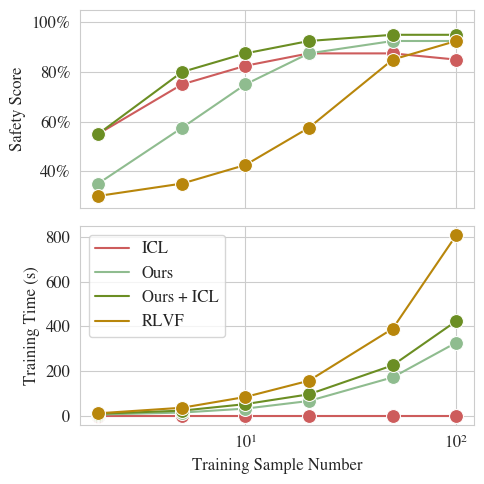

In [4]:
from matplotlib.ticker import PercentFormatter

df = pd.read_csv('results/safe-score-data-size.csv')

df['Category'] = df['Category'].replace('In-Context', 'ICL')
df['Category'] = df['Category'].replace('Ours + In-Context(2)', 'Ours + ICL(2)')
df['Category'] = df['Category'].replace('Ours + In-Context(5)', 'Ours + ICL')
df['Category'] = df['Category'].replace('Fine-tuning (RLVF)', 'RLVF')
df = df[df['Category'] != 'Ours + ICL(2)']

fig, axs = plt.subplots(2,1, figsize=(5,5), sharex=True)

kwargs = dict(marker='o', markersize=10, palette=['#CD5C5C', '#8FBC8F', '#6B8E23', '#B8860B'])

ax = axs[0]
sns.lineplot(df, x='Training Sample Number', y='Safety Score', hue='Category', ax=ax, **kwargs)
ax.set_ylim(0.25, 1.05)
# ax.legend(loc="lower right", ncol = 1)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))  # format as percentages
ax.legend([],[], frameon=False)
plt.xscale('log')

ax = axs[1]
# ax = sns.lineplot(df, x='Training Sample Number',y='Training Time (s)',hue='Category', marker='o', linestyle='dashed')
sns.lineplot(df, x='Training Sample Number', y='Training Time (s)', hue='Category', ax=ax, **kwargs)
ax.legend(loc="upper left", ncol = 1)
plt.xscale('log')


save_fig('sample-size-accuracy-n-time.pdf')

In [36]:
# fig, ax = plt.subplots(figsize=(4,3))
# # ax = sns.lineplot(df, x='Training Sample Number',y='Training Time (s)',hue='Category', marker='o', linestyle='dashed')
# sns.lineplot(df, x='Training Sample Number', y='Training Time (s)', hue='Category', marker='o', markersize=8, ax=ax)
# ax.legend(loc="upper left", ncol = 1)
# plt.xscale('log')
# save_fig('sample-size-time.pdf')

In [78]:
# df1 = pd.read_csv('results/num_spec.csv')

# df1['Method'] = 'RLVF'
# df1['Safety Score'] = df1['Safety Score'].to_numpy()/15

# df2 = pd.read_csv('results/safe-score-step.csv')
# df2['Method'] = 'Ours'

# # Concatenate the dataframes
# df_combined = pd.concat([df1, df2], ignore_index=True)
# df_combined = df_combined[df_combined['Category'] == 'Validation']

# # Create a figure to display the results
# fig, ax = plt.subplots(figsize=(6,3))
# # sns.boxplot(df_combined, x='Step', y='Safety Score', hue='Method')
# sns.lineplot(df_combined, x='Step', y='Safety Score', marker='o', hue='Method')
# ax.set_ylim(0.35, 1.05)
# ax.set_title('Safety Score vs. Number of Steps')
# ax.legend(loc="lower right", ncol=1)
# # save_fig('combined-safety-scores.pdf')
# # df_combined


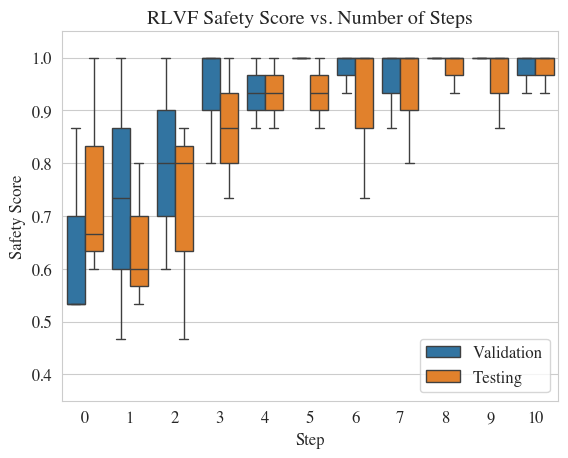

In [ ]:
df1 = pd.read_csv('results/num_spec.csv')

df1['Method'] = 'RLVF'
df1['Safety Score'] = df1['Safety Score'].to_numpy()/15

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})
plt.rcParams.update({'font.family': 'Times'})

ax = sns.boxplot(df1, x='Step',y='Safety Score',hue='Category')
ax.set_ylim(0.35, 1.05)
ax.set_title('RLVF Safety Score vs. Number of Steps')
ax.legend(loc="lower right", ncol = 1)

save fig => ./exported_imgs/safety_optimization_step.pdf


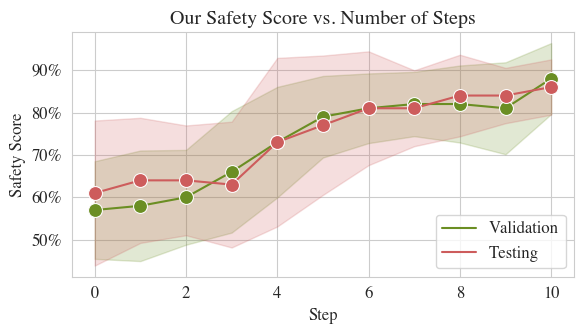

In [14]:
df = pd.read_csv('results/safe-score-step.csv')

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})
plt.rcParams.update({'font.family': 'Times'})

# df = pd.read_csv('win_counts-chess.csv')
# df['Win Rate'] = df['Win Rate'].to_numpy()/20
fig, ax = plt.subplots(1,1, figsize=(6,3.5))

kwargs = dict(marker='o', markersize=10, palette=['#6B8E23', '#CD5C5C'])

ax = sns.lineplot(df, x='Step',y='Safety Score',hue='Category', errorbar='sd', **kwargs)
# ax.set_ylim(0.35, 1.05)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))  # format as percentages
ax.set_title('Our Safety Score vs. Number of Steps')
ax.legend(loc="lower right", ncol = 1)
# ax.legend(loc="upper left", mode = "expand", ncol = 2)
# ax.set_title('Against ChessGPT on Chess')
save_fig('safety_optimization_step.pdf')

save fig => ./exported_imgs/safety_testing.pdf


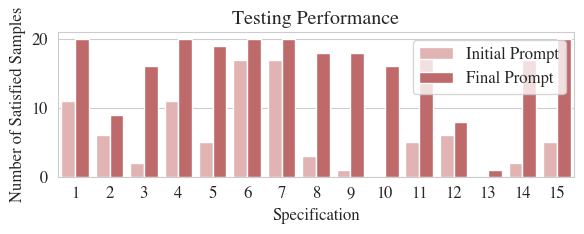

In [ ]:
df = pd.read_csv('results/safety-testing.csv')

fig, ax = plt.subplots(1,1, figsize=(6,2.5))

df['Category'] = df['Category'].replace('Step 0', 'Initial Prompt')
df['Category'] = df['Category'].replace('Step 10', 'Final Prompt')

kwargs = dict(palette=["#E9ABAB", '#CD5C5C'])

sns.barplot(data=df, x="Specification", y="Number of Satisfied Samples", hue="Category", ax=ax, **kwargs)
# ax.set_ylim(0.5, 0.8)
ax.set_title('Testing Performance')
ax.legend(title='')
# plt.savefig('size.png')
save_fig('safety_testing.pdf')

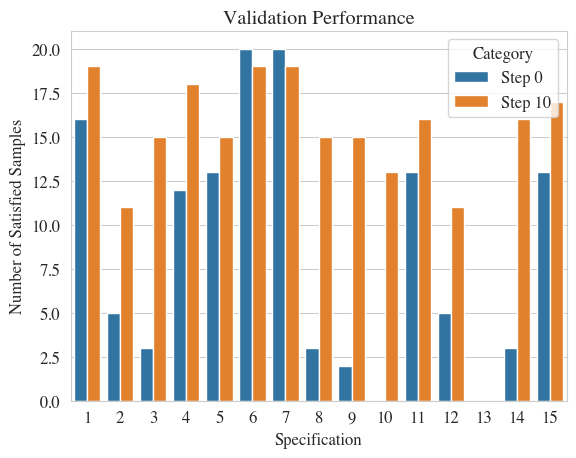

In [15]:
df = pd.read_csv('results/safety-validation.csv')

ax = sns.barplot(data=df, x="Specification", y="Number of Satisfied Samples", hue="Category")
ax.set_title('Validation Performance')
plt.rcParams.update({'font.size': 12})
plt.rcParams.update({'font.family': 'Times'})